In [ ]:
# Copyright 2023 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.


## Experiment
# This is an Experimental release. Experiments are focused on validating a
# prototype and are not guaranteed to be released. Experiments are covered
# by the [Pre-GA Offerings Terms](https://cloud.google.com/terms/service-terms)
# of the Google Cloud Platform Terms of Service. They are not intended for
# production use or covered by any SLA,  support obligation, or deprecation
# policy and might be subject to backward-incompatible changes.

## Overview

This tutorial demonstrates how to use the Distillation Step by Step on the Vertex AI platform.

We developed the distilling step-by-step (DSS) method ([paper](https://arxiv.org/abs/2305.02301v1)) that can enrich customer’s data by eliciting the reasoning process (rationales) from a large language model (LLM). This new mechanism has shown to be able to (a) train smaller models that outperform LLMs, and (b) achieves so by leveraging less training data needed by fine-tuning or distillation. Our method extracts LLM rationales as additional supervision within a multi-task training framework.


For more information about DSS on Vertex AI, see the following resources:

1. [Distilling Step-by-Step! Outperforming Larger Language Models with Less Training Data and Smaller Model Sizes](https://arxiv.org/abs/2305.02301v1)
2. [Vertex AI pipeline](https://cloud.google.com/vertex-ai/docs/pipelines/introduction)


### Dataset

This tutorial uses the `Wikilingua` in the public bucket `gs://cloud-samples-data/ai-platform-unified/datasets/distillation/`, which was generated from the [Wikilingua EN dataset](https://github.com/esdurmus/Wikilingua)


### Objective

In this notebook, you will learn how to run DSS on Vertex AI.
The tutorial covers the following steps:
1. **Setup**: Importing the required libraries and setting your global variables.
2. **Configure parameters**: Setting the appropriate parameter values for the training job.
3. **Train on Vertex Pipeline**: Submitting a training job using json input.


### Costs


This tutorial uses billable components of Google Cloud:

* Vertex AI
* Cloud Storage

During Experimental Release, the model tuning is free of charge. However, if you deploy the model, serving cost will incure as usual.

Learn about [Vertex AI
pricing](https://cloud.google.com/vertex-ai/pricing) and [Cloud Storage
pricing](https://cloud.google.com/storage/pricing), and use the [Pricing
Calculator](https://cloud.google.com/products/calculator/)
to generate a cost estimate based on your projected usage.

# Allow list
Please ask your Google's contact to get your project in allow list to run the pipeline.

# Initial Set Up

### Set up your local development environment

**If you are using Colab or Google Cloud Notebooks**, your environment already meets
all the requirements to run this notebook. You can skip this step.

**Otherwise**, make sure your environment meets this notebook's requirements.
You need the following:

* The Google Cloud SDK
* Git
* Python 3
* virtualenv
* Jupyter notebook running in a virtual environment with Python 3

The Google Cloud guide to [Setting up a Python development
environment](https://cloud.google.com/python/setup) and the [Jupyter
installation guide](https://jupyter.org/install) provide detailed instructions
for meeting these requirements. The following steps provide a condensed set of
instructions:

1. [Install and initialize the Cloud SDK.](https://cloud.google.com/sdk/docs/)

1. [Install Python 3.](https://cloud.google.com/python/setup#installing_python)

1. [Install
   virtualenv](https://cloud.google.com/python/setup#installing_and_using_virtualenv)
   and create a virtual environment that uses Python 3. Activate the virtual environment.

1. To install Jupyter, run `pip3 install jupyter` on the
command-line in a terminal shell.

1. To launch Jupyter, run `jupyter notebook` on the command-line in a terminal shell.

1. Open this notebook in the Jupyter Notebook Dashboard.

### Install additional packages

Install additional package dependencies not installed in your notebook environment, such as XGBoost, AdaNet, or TensorFlow Hub. Use the latest major GA version of each package.

In [ ]:
import os

# The Google Cloud Notebook product has specific requirements
IS_GOOGLE_CLOUD_NOTEBOOK = os.path.exists("/opt/deeplearning/metadata/env_version")

# Google Cloud Notebook requires dependencies to be installed with '--user'
USER_FLAG = ""
if IS_GOOGLE_CLOUD_NOTEBOOK:
    USER_FLAG = "--user"

In [ ]:
! pip3 install --upgrade google-cloud-aiplatform -q
! pip3 install kfp -q
! pip install -U google-cloud-aiplatform "shapely<2" -q
! pip install -U google_cloud_pipeline_components -q
# ! gcloud components update --quiet

### Restart the kernel

After you install the additional packages, you need to restart the notebook kernel so it can find the packages.

In [ ]:
# Automatically restart kernel after installs
import os

if not os.getenv("IS_TESTING"):
    # Automatically restart kernel after installs
    import IPython

    app = IPython.Application.instance()
    app.kernel.do_shutdown(True)

### Set up your Google Cloud project

**The following steps are required, regardless of your notebook environment.**

1. [Select or create a Google Cloud project](https://console.cloud.google.com/cloud-resource-manager). When you first create an account, you get a $300 free credit towards your compute/storage costs.

1. [Make sure that billing is enabled for your project](https://cloud.google.com/billing/docs/how-to/modify-project).

1. [Enable the Vertex AI API](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com).

1. If you are running this notebook locally, you will need to install the [Cloud SDK](https://cloud.google.com/sdk).

1. Enter your project ID in the cell below. Then run the cell to make sure the
Cloud SDK uses the right project for all the commands in this notebook.

**Note**: Jupyter runs lines prefixed with `!` as shell commands, and it interpolates Python variables prefixed with `$` into these commands.

#### Set your project ID

**If you don't know your project ID**, you may be able to get your project ID using `gcloud`.

In [ ]:
import os

PROJECT_ID = ""

# Get your Google Cloud project ID from gcloud
if not os.getenv("IS_TESTING"):
    shell_output = !gcloud config list --format 'value(core.project)' 2>/dev/null
    PROJECT_ID = shell_output[0]
    print("Project ID: ", PROJECT_ID)

Otherwise, set your project ID here.

In [ ]:
# PROJECT_ID = "YOUR_PROJECT_ID"  # @param {type:"string"}

! gcloud config set project $PROJECT_ID

### Authenticate your Google Cloud account

**If you are using Google Cloud Notebooks**, your environment is already
authenticated. Skip this step.

**If you are using Colab**, run the cell below and follow the instructions
when prompted to authenticate your account via oAuth.

**Otherwise**, follow these steps:

1. In the Cloud Console, go to the [**Create service account key**
   page](https://console.cloud.google.com/apis/credentials/serviceaccountkey).

2. Click **Create service account**.

3. In the **Service account name** field, enter a name, and
   click **Create**.

4. In the **Grant this service account access to project** section, click the **Role** drop-down list. Type "Vertex AI"
into the filter box, and select
   **Vertex AI Administrator**. Type "Storage Object Admin" into the filter box, and select **Storage Object Admin**.

5. Click *Create*. A JSON file that contains your key downloads to your
local environment.

6. Enter the path to your service account key as the
`GOOGLE_APPLICATION_CREDENTIALS` variable in the cell below and run the cell.

In [ ]:
import os
import sys

# If you are running this notebook in Colab, run this cell and follow the
# instructions to authenticate your GCP account. This provides access to your
# Cloud Storage bucket and lets you submit training jobs and prediction
# requests.

# The Google Cloud Notebook product has specific requirements
IS_GOOGLE_CLOUD_NOTEBOOK = os.path.exists("/opt/deeplearning/metadata/env_version")

# If on Google Cloud Notebooks, then don't execute this code
if not IS_GOOGLE_CLOUD_NOTEBOOK:
    if "google.colab" in sys.modules:
        from google.colab import auth as google_auth

        google_auth.authenticate_user()

    # If you are running this notebook locally, replace the string below with the
    # path to your service account key and run this cell to authenticate your GCP
    # account.
    elif not os.getenv("IS_TESTING"):
        %env GOOGLE_APPLICATION_CREDENTIALS ''

# Data Input format requirement

For summarization tasks, the user will prepare the json file to have "source" and "target" fields of each example.
"source" is the original document
"target" is the label of summarization. If your task does not have "target", just leave it blank (aka.""). And set the argument gt_prompt as below so that the teacher model can generate the ground truth.

Example of a simple json file



```
{"source": "This is long document 1", "target": "document 1."}
{"source": "This is long document 2. ", "target": "document 2."}
```

We prepared a small dataset based on Wikilingua dataset and put in the public gcs: `/gcs/cloud-samples-data/ai-platform-unified/datasets/distillation/sample_50.json`




### Import libraries and define constants

In [ ]:
from datetime import datetime
from google.cloud import aiplatform

_DISTILLATION_URI = 'https://us-kfp.pkg.dev/ml-pipeline/research/distillation/preview-v1'

# Run the Distillation Step by Step Pipeline
The following command runs the pipeline and write the demos into the GCS bucket.
This step takes a while. If you don't have time to wait, you can stop the cell and uncomment a line in the next cell to see the results from a previously generated run.



## Set permission in your project
You will also need to give your service account to have Vertex AI User, Artifact Registry Reader and Storage Object Admin like this

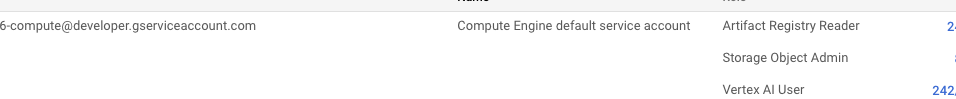

## **MUST** Update **these parameters** based your project information
1. PROJECT_ID: your project id
2. SERVICE_ACCOUNT: The service account associated with your project
3. PIPELINE_ROOT: the GCS location where the pipeline store data



In [ ]:
# PROJECT_ID = 'YOUR_PROJECT_ID' #@param {type:"string"}
# SERVICE_ACCOUNT = 'YOUR_PROJECT_NUMBER-compute@developer.gserviceaccount.com' #@param {type:"string"}
# PIPELINE_ROOT = 'gs://distillation-dev/exp' #@param {type:"string"}

## Update these parameters based on your use case. You are likely need to change:
1. input_dataset
2. input_test_dataset (or test_size)
3. prompt

In [ ]:
current_time = datetime.utcnow().strftime('%y%m%d%H%M%S')



ENABLE_CACHING = True #@param {type:"boolean"}
LOCATION = 'asia-southeast1' #@param {type:"string"}

version='latest' #@param {type:"string"}
input_dataset = '/gcs/cloud-samples-data/ai-platform-unified/datasets/distillation/sample_50.json' #@param {type:"string"}
input_test_dataset = '/gcs/cloud-samples-data/ai-platform-unified/datasets/distillation/sample_5.json' #@param {type:"string"}
test_size = 0.0 #@param {type:"slider", min:0.0, max:1.0, step:0.1}
rationale_prompt_prefix = '' #@param {type:"string"}
rationale_prompt_suffix='. TL, DR. Let us think step by step.' #@param {type:"string"}
gt_prompt_prefix='' #@param {type:"string"}
gt_prompt_suffix='Let us summarize the document.' #@param {type:"string"}
force_user_gt = 'False' #@param ['False', 'True']{type:"string"}
teacher_model_type = 'text-bison@001' #@param {type:"string"}
student_model_type = 'text_gecko' #@param {type:"string"}
max_gen_length_gt = 256 #@param {type:"integer"}
max_gen_length_rationale = 256 #@param {type:"integer"}
num_inference_workers =3 #@param {type:"integer"}
alpha=0.5 #@param {type:"number"}
finetuning_steps = 100 #@param {type:"integer"}
batch_size = 2 #@param {type:"integer"}
base_learning_rate=0.001 #@param {type:"number"}
student_temperature = 1 #@param {type:"integer"}
is_run_eval_before_training = 'False' #@param ['False', 'True'] {type:"string"}
eval_period = 1000 #@param {type:"integer"}
checkpoint_period = 1000 #@param {type:"integer"}
machine_type = 'a2-highgpu-2g' #@param {type:"string"}
accelerator_count = 2 #@param {type:"integer"}


PARAMS = {
    'project': PROJECT_ID,
    'location': LOCATION,
    'version': version,
    'input_dataset': input_dataset,
    'input_test_dataset': input_test_dataset,
    'test_size': test_size,
    'rationale_prompt_prefix': rationale_prompt_prefix,
    'rationale_prompt_suffix': rationale_prompt_suffix,
    'gt_prompt_prefix': gt_prompt_prefix,
    'gt_prompt_suffix': gt_prompt_suffix,
    'force_user_gt': force_user_gt,
    'student_model_type': student_model_type,
    'teacher_model_type': teacher_model_type,
    'max_gen_length_gt': max_gen_length_gt,
    'max_gen_length_rationale': max_gen_length_rationale,
    'num_inference_workers': num_inference_workers,
    'alpha': alpha,
    'finetuning_steps': finetuning_steps,
    'batch_size': batch_size,
    'base_learning_rate': base_learning_rate,
    'student_temperature': student_temperature,
    'is_run_eval_before_training':  is_run_eval_before_training,
    'eval_period': eval_period,
    'checkpoint_period': checkpoint_period,
    'machine_type': machine_type,
    'accelerator_count': accelerator_count,
}


job = aiplatform.PipelineJob(display_name = 'distillation-external'+ current_time,
                             pipeline_root=PIPELINE_ROOT,
                             template_path = _DISTILLATION_URI,
                             project = PROJECT_ID,
                             location = LOCATION,
                             parameter_values = PARAMS,
                             enable_caching=ENABLE_CACHING)

job.submit(service_account=SERVICE_ACCOUNT)
job.wait()

## Configure parameters

The following table shows the parameters for the distillation pipeline job:

| Parameter | Data type | Description | Required |
|--|--|--|--|
| `location` | string | region to upload the model. | Yes |
| `service_account` | string | The service account is used to run the pipeline. | Yes |
| `pipeline_root` | string | The gcs location to store the pipeline. | Yes |
| `input_dataset` | string | Cloud Storage pattern where training data is stored. | Yes |
| `input_test_dataset` | string | Cloud Storage pattern where test data is stored. | No |
| `test_size` | float | Fraction of data is for testing. Only test_size or input_test_dataset should be set. | No |
| `rationale_prompt_prefix` | string | The prompt appends before the prompt to extract the rationale from the teacher model. The prefix is also helpful in few-shot learning.| No |
| `rationale_prompt_suffix` | string | The prompt appends after input to extract the rationale from the teacher model. Example is ". TL, DR. Let us think step by step.| No |
| `gt_prompt_prefix` | string | The prompt appends before the prompt to extract the ground truth from the teacher model. The prefix is also helpful in few-shot learning.| No |
| `gt_prompt_suffix` | string | The prompt appends after input to extract the ground truth from the teacher model. Example is ".  Let us summarize the document.| No |
| `teacher_model_type` | string | The model type of teacher model. The default is "text-bison@001". We also support "text-bison@latest" | No |
| `student_model_type` | string | The model type of student model. The default is "text_gecko". We will support text_otter soon. | No |
| `max_gen_length_gt` | int | The max lenghth of generated ground truth. | No |
| `max_gen_length_rationale` | int | The max lenghth of generated rationale. | No |
| `finetuning_steps` | int | Additional steps to finetune to init checkpoint steps. The default is 1000. | No |
| `base_learning_rate` | float | The learning rate of trainer. Default is 0.001. | No |
| `student_temperature` | float | Temperature for student model. The default is 1.0. | No |
| `batch_size` | int | Batch size for training. The default is 2. | No |
| `eval_period` | int | The number of train steps between each evaluation. The default is 1000. | No |
| `enable_caching` | boolean | Whether we want to cache the previous run. The default is True. Use the False to force a fresh run. | No |
| `machine_type` | string | Machine type . | Yes |
| `region` | string | Region to submit the job to. | No |



# Understand pipeline



### Main artifacts
When click to *evaluation-process* component, you will see two files:

*   prediction_file: {“inputs”: inputs, “prediction”: prediction}
*   target_file {“target”: target}



### Model in Vertex Model Registry
There will be a pipeline component to upload your model to Vertex AI Model Registry. Click on the model artifact from pipleine graph to find the model URI, which will redirect to the uploaded model in model registry. You can then create the endpoint to serve the model.

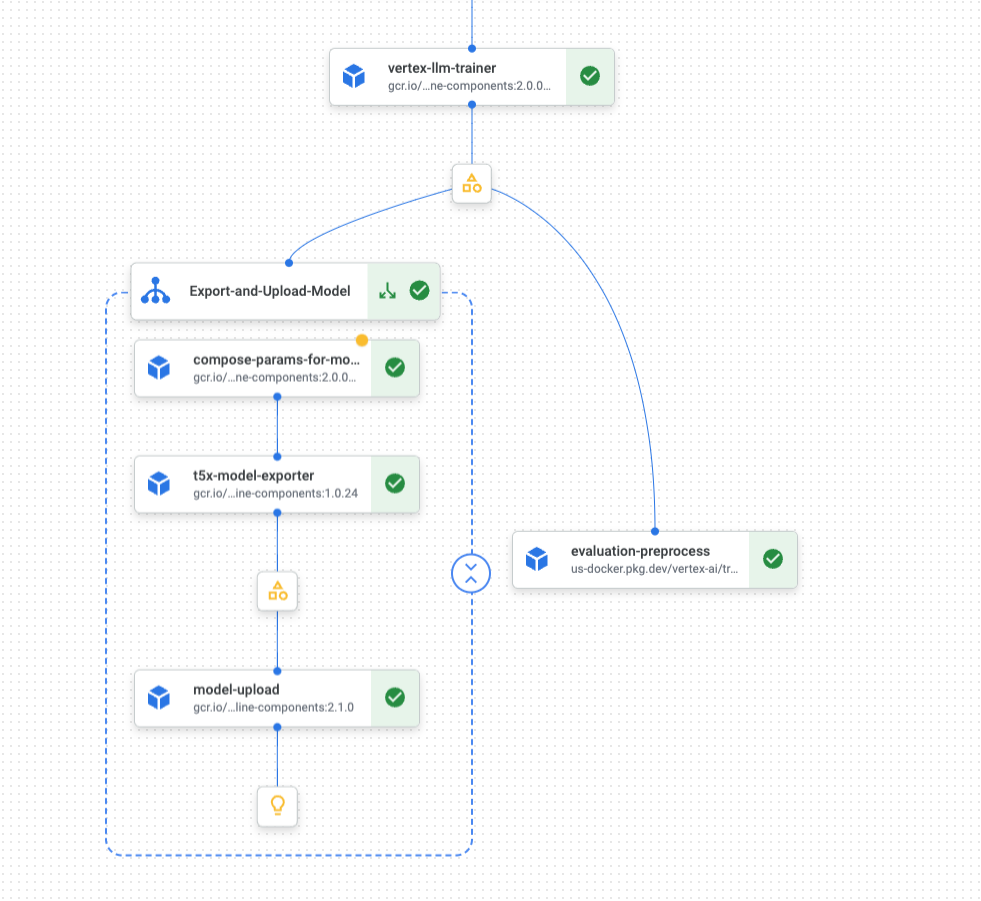





# Deploy and serving model.
The pipeline will upload the fine tuned student model to Vertex Model Registry. Then, you can deploy model to end point by selection **Deploy to endpoint**. You should select A100 for text-gecko student model. Then, you can query the model.

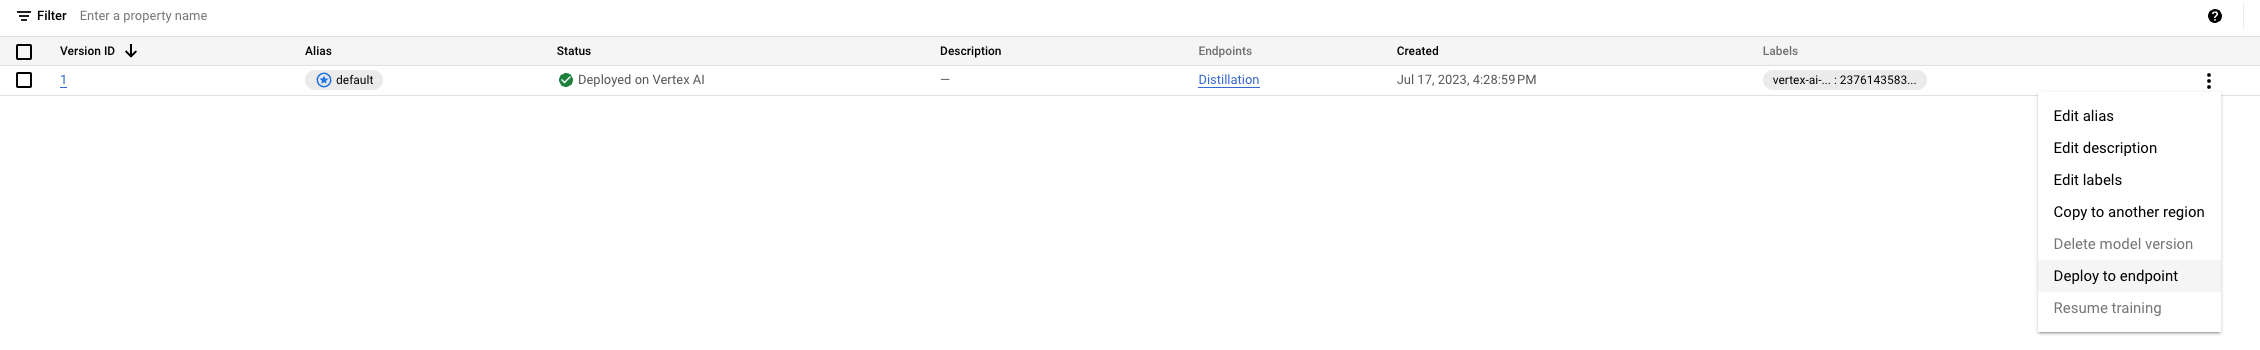

In [ ]:
# List all endpoint. In our project, we deployed one model in asia-southeast1
REGION='asia-southeast1'
!gcloud ai endpoints list --region={REGION}

In [ ]:
endpoint = aiplatform.Endpoint('projects/YOUR_PROJECT_NUMBER/locations/asia-southeast1/endpoints/YOUR_ENDPOINT_ID')
print("Endpoint: ", endpoint)

Copy below commands and run **in your command line**, you can see the prediction of the distillation model

In [ ]:
ENDPOINT_ID="YOUR_ENDPOINT_ID"
PROJECT_ID="YOUR_PROJECT_NUMBER"

curl \
-X POST \
-H "Authorization: Bearer $(gcloud auth print-access-token)" \
-H "Content-Type: application/json" \
https://asia-southeast1-aiplatform.googleapis.com/v1/projects/${PROJECT_ID}/locations/asia-southeast1/endpoints/${ENDPOINT_ID}:predict -d \
$'{
  "instances": [
    { "text_batch": "At a minimum, employers often offer training on company-specific bookkeeping systems and programs. Your employer may also pay for other professional development opportunities, such as software classes or seminars. Professional development will help you expand your skill set, boost your performance, and advance your career. Take advantage of every opportunity that comes your way! Depending on the association, you will need 1 to 2 years of professional experience and a 2-year degree to take the exam. To apply, visit the website of your national or regional certified bookkeeper association. Fill out the application form, pay the exam fees, then sit for the exam at the designated testing center. Can you summarize this document?"}
  ],
  "parameters": {
    "temperature": 0.2,
    "maxOutputTokens": 256,
    "topK": 40,
    "topP": 0.95
  }
}'